In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
# Notebooks run from the notebooks folder, so the src folder is added to the path.
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, rasterio, matplotlib.pyplot as plt
from tqdm import tqdm
import config

In [2]:
import json
from matplotlib.colors import ListedColormap
from rasterio.windows import Window
from prepare import load_chips, flatten
from metrics import split_chips, flat_ndvi, calculate_ndvi, score

_, _, test = split_chips(load_chips())
threshold = json.loads(config.NDVI_THRESHOLD_FILE.read_text())["threshold"]
test_ndvi, test_truth, test_classes = flat_ndvi(test), flatten(test, "msk"), flatten(test, "lc8")
# Each pixel falls into one outcome group.
predicted = test_ndvi > threshold
false_alarms, missed, found = predicted & (test_truth == 0), ~predicted & (test_truth == 1), predicted & (test_truth == 1)

Tiles: 1127 train, 392 validation, 392 test


In [3]:
# The land cover class of every pixel wrongly called canopy.
classes, counts = np.unique(test_classes[false_alarms], return_counts=True)
for cls, count in zip(classes, counts):
    print(f"{config.CLASS_NAMES[cls]:12s} {100 * count / counts.sum():5.1f}%")

grass/shrub   52.0%
bare ground    0.6%
building      12.2%
road           8.7%
other paved   26.4%
railroad       0.1%


Grass/shrub is expected as the highest false positive as NDVI cannot differentiate them.

In [4]:
# Mean band values for detected canopy, missed canopy, and everything else.
bands = np.concatenate([c["img"].reshape(4, -1) for c in test], axis=1)
for name, group in [("found", found), ("missed", missed), ("not canopy", test_truth == 0)]:
    r, g, b, n = bands[:, group].mean(axis=1)
    print(f"{name:10s} R {r:5.1f}  G {g:5.1f}  B {b:5.1f}  NIR {n:5.1f}  brightness {bands[:, group].mean():5.1f}")

found      R  95.4  G 100.3  B  78.4  NIR 147.9  brightness 105.5
missed     R 103.6  G 103.3  B 102.1  NIR  76.2  brightness  96.3
not canopy R 130.6  G 133.1  B 130.1  NIR  97.9  brightness 122.9


Shadow is a potential factor in the reason for missed canopy using NDVI. The elevated blue light value and low near IR and brightness leads to this conclusion.

In [10]:
# Three subsets spread diagonally across the study area, so no result rests on one spot.
SIZE = 2048
LOCATIONS = [(int(f * (config.STUDY_AREA.height - SIZE)), int(f * (config.STUDY_AREA.width - SIZE))) for f in (0.1, 0.5, 0.9)]


def read_subset(row, col):
    """Read the NAIP image and aligned labels for one square subset."""
    window = Window(config.STUDY_AREA.col_off + col, config.STUDY_AREA.row_off + row, SIZE, SIZE)
    with rasterio.open(config.NAIP_FILE) as photo:
        image = photo.read(window=window)
    with rasterio.open(config.LABELS_FILE) as labels:
        mask = labels.read(1)[row:row + SIZE, col:col + SIZE]
    return window, image, mask


# The gain from the best shift at each location is stored for Cell 6.
alignment = {}
for row, col in LOCATIONS:
    _, image, mask = read_subset(row, col)
    vegetation = calculate_ndvi(image) > threshold
    # Every shift of the labels up to 8 pixels is scored.
    shifts = {(dr, dc): score(vegetation, np.roll(mask, (dr, dc), axis=(0, 1)))["iou"]
              for dr in range(-8, 9) for dc in range(-8, 9)}
    best = max(shifts, key=shifts.get)
    alignment[(row, col)] = (shifts[best] - shifts[(0, 0)], best)
    print(f"Location ({row}, {col}): IoU {shifts[(0, 0)]:.3f} unshifted | best {shifts[best]:.3f} at shift {best}")

Location (1071, 796): IoU 0.589 unshifted | best 0.603 at shift (0, -1)
Location (5356, 3982): IoU 0.724 unshifted | best 0.729 at shift (1, 1)
Location (9640, 7168): IoU 0.495 unshifted | best 0.572 at shift (0, 4)


Shifting the alignment has the most effect at the eastern edge of the image tile. This likely is a result of the position of the camera used to capture the NAIP imagery. The LiDAR derived canopy data is at the true position of the canopy. Any tall objects at the edge of the imagery would distort and lean more than at the center, leading to a decrease in IoU.

In [11]:
# At the location with the largest offset, the labels are realigned and the miss rate is recalculated.
_, image, mask = read_subset(*LOCATIONS[2])
vegetation = calculate_ndvi(image) > threshold
for label, labels in [("as aligned", mask), ("shifted 4 px east", np.roll(mask, (0, 4), axis=(0, 1)))]:
    print(f"{label:18s} missed canopy rate {100 * (~vegetation & (labels == 1)).sum() / (labels == 1).sum():.1f}%")

as aligned         missed canopy rate 29.4%
shifted 4 px east  missed canopy rate 22.5%


In [6]:
from rasterio.warp import reproject, transform_bounds
from rasterio.enums import Resampling


def canopy_fraction(window):
    """Calculate the fraction of each NAIP pixel in the window that is covered by canopy."""
    with rasterio.open(config.NAIP_FILE) as photo:
        target_transform, target_crs, bounds = photo.window_transform(window), photo.crs, photo.window_bounds(window)
    with rasterio.open(config.LANDCOVER_FILE) as source:
        left, bottom, right, top = transform_bounds(target_crs, source.crs, *bounds)
        # A 100 ft margin prevents the rotated corners from being clipped.
        source_window = source.window(left - 100, bottom - 100, right + 100, top + 100).round_offsets().round_lengths()
        canopy = (source.read(1, window=source_window) == config.CANOPY_CLASS).astype("float32")
        source_transform, source_crs = source.window_transform(source_window), source.crs
    # Averaging a binary layer gives the share of each pixel covered by canopy.
    fraction = np.zeros((SIZE, SIZE), dtype="float32")
    reproject(canopy, fraction, src_transform=source_transform, src_crs=source_crs,
              dst_transform=target_transform, dst_crs=target_crs, resampling=Resampling.average)
    return fraction


# Each subset is stored so Cell 7 can display the clearest example.
subsets = {}
for row, col in LOCATIONS:
    window, image, mask = read_subset(row, col)
    fraction = canopy_fraction(window)
    subset_missed = (calculate_ndvi(image) <= threshold) & (mask == 1)
    subsets[(row, col)] = (image, subset_missed, fraction)
    covered = fraction[subset_missed]
    print(f"Location ({row}, {col}): fully covered {100 * (covered >= 0.95).mean():.1f}% | "
          f"boundary {100 * ((covered >= 0.5) & (covered < 0.7)).mean():.1f}%")

Location (1071, 796): fully covered 77.4% | boundary 8.6%
Location (5356, 3982): fully covered 81.0% | boundary 7.2%
Location (9640, 7168): fully covered 80.6% | boundary 7.3%


The distribution shows that missed canopy is not specific to pixels at the boundary of canopy leaves and sidewalk or pavement.

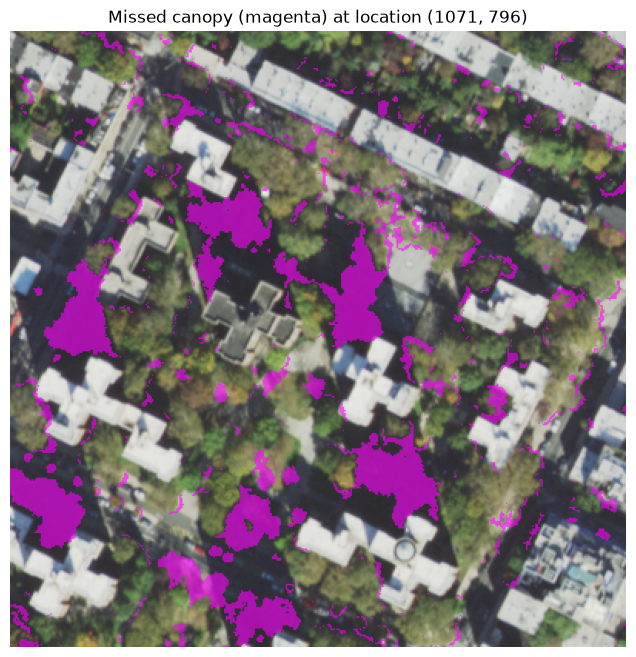

In [7]:
# The 400 pixel area with the most fully covered missed canopy, across all three subsets.
_, key, r, c = max(((miss & (frac >= 0.95))[r:r + 400, c:c + 400].sum(), key, r, c)
                   for key, (img, miss, frac) in subsets.items()
                   for r in range(0, SIZE - 399, 400) for c in range(0, SIZE - 399, 400))
image, subset_missed, fraction = subsets[key]
target = (subset_missed & (fraction >= 0.95))[r:r + 400, c:c + 400]
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(image[:3, r:r + 400, c:c + 400], (1, 2, 0)))
plt.imshow(np.ma.masked_where(~target, target), cmap=ListedColormap(["#ff00ff"]), alpha=0.6)
plt.title(f"Missed canopy (magenta) at location {key}"); plt.axis("off")
plt.savefig(config.FIGURES / "02b_missed_canopy.png", dpi=120, bbox_inches="tight"); plt.show()

The missed canopy (magenta) is clearly sitting in the shadow of the buildings.

In [8]:
def building_nearby(building, direction, reach=40):
    """Mark pixels that have a building within reach (40 pixels is about 24 m) in one direction."""
    marked = np.zeros_like(building)
    for s in range(1, reach + 1):
        # Rows increase southward in a north-up raster, so a building to the south has a higher row number.
        target, source = {"south": (np.s_[:-s, :], np.s_[s:, :]), "north": (np.s_[s:, :], np.s_[:-s, :]),
                          "east": (np.s_[:, :-s], np.s_[:, s:]), "west": (np.s_[:, s:], np.s_[:, :-s])}[direction]
        marked[target] |= building[source]
    return marked


for direction in ["south", "north", "east", "west"]:
    nearby = np.concatenate([building_nearby(c["lc8"] == config.BUILDING_CLASS, direction).ravel() for c in test])
    print(f"Building to the {direction:5s}  missed {100 * nearby[missed].mean():5.1f}%  found {100 * nearby[found].mean():5.1f}%")

Building to the south  missed  46.1%  found  39.0%
Building to the north  missed  41.8%  found  42.7%
Building to the east   missed  39.3%  found  31.8%
Building to the west   missed  44.4%  found  28.8%


The sun in November over NYC is in the southern sky, and based from the slight west-skwed shadows, the image was taken in the morning. Buildings to the south and/or west of canopy lead to a large shadow affecting the canopy reading. However, the earlier alignment-shift test also revealed that canopy on the eastern side of the tile has the most lean (crown sits eastward of the tree trunk). These two factors, building position and feature lean, are confounding causes in producing negative NDVI values.